# Plot

`ax.plot()` is the primary function for creating 2D line plots though it can also be used to visualize point data (similar to `scatter()` though this one has a few more options).  It is used primarily to visualizing continuous data as connected lines and/or markers.

Many of the parameters that are used in `.plot()` are also found in many other Matplotlib chart types so this tutorial will provide us an opportunity to learn a bit more about them.

Sample syntax:
>```python
>ax = ax.plot(x, y)                    # Simple line
>ax = ax.plot(x, y, 'r--')             # Red dashed line
>ax = ax.plot(x, y, marker='o')        # Line with markers
>```

The `plot()` function has many parameters. We shall explore some in more detail than others.

- `x` — X-axis data; default: `None` (uses `range(len(y))`); range: 1D array-like of numeric values
- `y` — Y-axis data; default: required; range: 1D array-like of numeric values
- `fmt` — MATLAB-style format string (color/marker/linestyle); default: `None`
- `color`  or `c` — Line/marker color
- `linestyle`  or `ls` — Style of connecting line; default: `'-'`
- `linewidth` or`lw`  — Line width in points
- `alpha` — Transparency; default: `None`; range: 0.0–1.0
- `marker` — Marker symbol; default: `None`.
- `markersize` or `ms` — Marker size in points.
- `markerfacecolor` or `mfc` — Marker fill color.
- `markeredgecolor` or  `mec` — Marker edge color; default: `'black'`.
- `markeredgewidth` or `mew` — Marker edge width.
- `label` — Label used in legend; default: `None`; range: string
- `markevery` — Marker placement control; default: `None`.
- `zorder` — Drawing order; default: `2`.
- `visible` — Whether the line is drawn; default: `True`.



We will first explore those parameters that affect the appearance of lines. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2026)

**Main line parameters:**

- Line Appearance:
    - `linestyle` or `ls` - Line style. 
        - `'none'` → No line
        - `'-'` or `'solid'` → Solid line
        - `'--'` or `'dashed'` → Dashed line
        - `'-.'` or `'dashdot'` → Dash-dot line
        - `':'` or `'dotted'` → Dotted line
    - `linewidth` or `lw` - Line width in points (default: 1.5)
    - `color` or `c` - Line color. ([more about color]())
        - *Named colors::* e.g. 'red', 'blue', 'green', 'orange', 'purple'
        - *Single letter codes:* e.g. 'r', 'g', 'b', 'c', 'm', 'y', 'k', 'w'
        - *Hex string codes:* e.g. '#FF5733', '#2E86AB'
        - *RGB/A tuples:*. A tuple with 3-4 values 0 to 1 representing RGB/A. e.g. (0.5, 0.2, 0.8)
    - `alpha` - Transparency (0.0-1.0)
- Drawing Style:
    - `drawstyle` or `ds` - How points are connected. Choose from:
        - `default` - Connect points with straight lines (standard behavior)
        - `steps` or `steps-pre` - Step function: horizontal line then vertical (step before point)
        - `steps-mid` - Step function: step halfway between points
        - `steps-post` - Step function: vertical line then horizontal (step after point)

Let's try different line styles and widths,

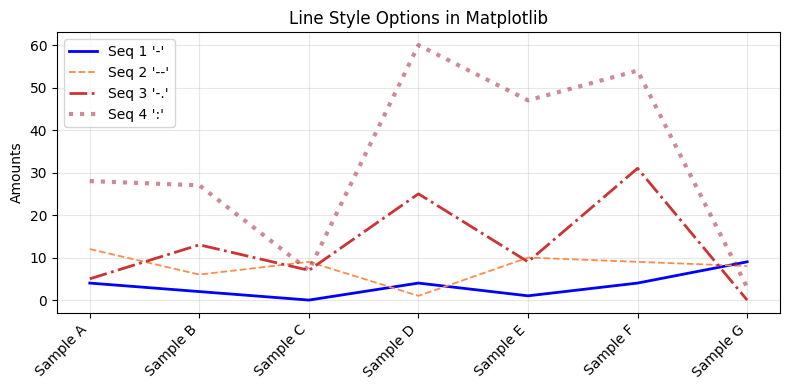

In [2]:
# Create data
n_lines = 4 # How many lines?
maxes = np.random.randint(10, 100, size=n_lines) # random maxima for each line
labels = ['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E', 'Sample F', 'Sample G']
n_datapoints = len(labels) # Number of x datapoints?
x = np.arange(len(labels))

# make highs broadcast to (n, m)
highs = np.broadcast_to(maxes, (n_datapoints, n_lines))
data = np.random.randint(0, highs).T   # integers in [0, highs-1]

# Create figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot the same data with different line styles
ax.plot(x, data[0], linestyle='-', lw=2, label="Seq 1 '-'", color='blue')
ax.plot(x, data[1], linestyle='dashed', lw=1.3, label="Seq 2 '--'", color='#fb8c4b')
ax.plot(x, data[2], linestyle='-.', lw=2, label="Seq 3 '-.'", color=(0.8, 0.2, 0.2))
ax.plot(x, data[3], linestyle=':', lw=3, label="Seq 4 ':'", color=(0.6, 0.1, 0.2, 0.5))

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Amounts')
ax.set_title('Line Style Options in Matplotlib')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now we will use different drawing styles (`ds`),

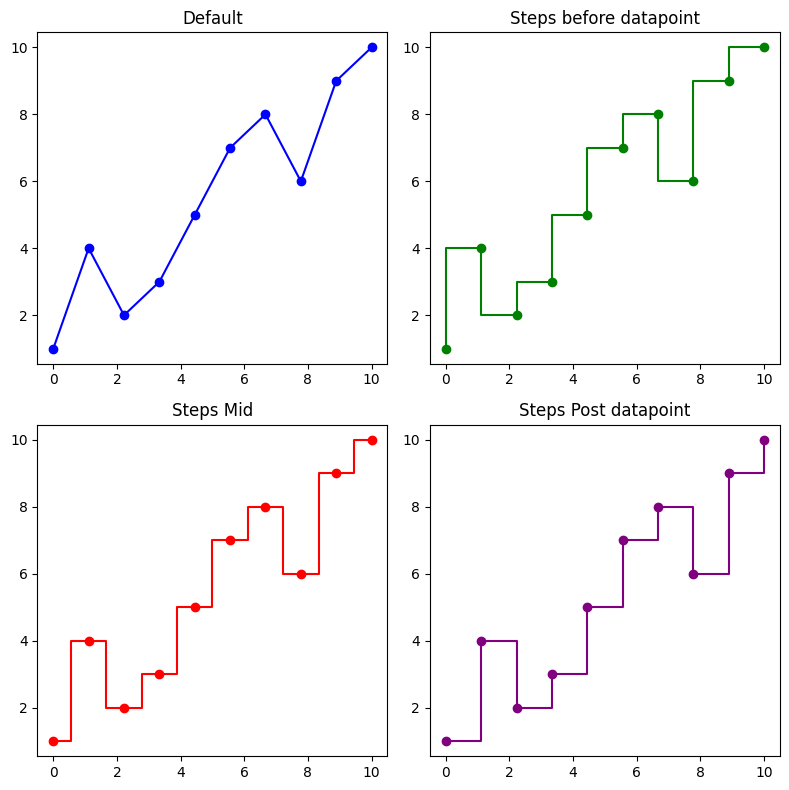

In [3]:
# Data
x = np.linspace(0, 10, 10)
y = [1, 4, 2, 3, 5, 7, 8, 6, 9, 10 ]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

axs[0,0].plot(x, y, drawstyle='default', marker='o', color='blue')
axs[0,0].set_title('Default')    # or ds='default'
axs[0,1].plot(x, y, ds='steps', marker='o', color='green') 
axs[0,1].set_title('Steps before datapoint')    # or ds='steps'
axs[1,0].plot(x, y, ds='steps-mid', marker='o', color='red')
axs[1,0].set_title('Steps Mid')  # or ds='steps-mid'        # or ds='steps-mid' 
axs[1,1].plot(x, y, ds='steps-post', marker='o', color='purple' )
axs[1,1].set_title('Steps Post datapoint')  # or ds='steps-post'

fig.tight_layout()
plt.show()

Let's now explore the marker parameters. Some of the parameters here are found elsewhere as well...

**Marker Parameters**
- `marker` — marker style (see below)
- `markersize` or `ms — size of the marker in points
- `markeredgecolor` or `mec` — color of the marker edge (same as line colors)
- `markeredgewidth` or `mew` - width of the marker edge 
- `markerfacecolor` or `mfc` — fill color of the marker (same as line colors)
- `markerfacecoloralt` or `mfcalt` — alternate fill color used with some fillstyles (e.g., left/right) in recent matplotlib versions (same as line colors)
- `markevery` - Controls which data points display markers (useful for reducing marker clutter on dense data). [See below](#fillstyle)
- `fillstyle` — fill style for fillable markers: 'full', 'left', 'right', 'bottom', 'top', 'none' (when using marker tuple or relevant marker types). [See below](#makevery)
- `alpha` — marker transparency (applies to face and edge unless colors are specified with alpha)
- `zorder` — drawing order (higher drawn on top)
- `label` — legend label for the plotted markers
- `clip_on` — whether the marker is clipped to the axes

Here are the built‑in marker styles supported by matplotlib (marker string and description):

1. ` '.' ` -  point
2. ` ',' ` -  pixel
3. ` 'o' ` -  circle
4. ` 'v' ` -  triangle_down
5. `'^'` - triangle_up
6. `'<'` - triangle_left
7. `'>'` - triangle_right
8. `'1'` - tri_down (tripod down)
9. `'2'` - tri_up
10. `'3'` - tri_left
11. `'4'` - tri_right
12. `'s'` - square
13. `'p'` - pentagon
14. `'*'` - star
15. `'h'` - hexagon1
16. `'H'` - hexagon2
17. `'+'` - plus
18. `'x'` - x
19. `'X'` - x (filled)
20. `'D'` - diamond
21. `'d'` - thin_diamond
22. `'|'` - vline
23. `'_'` - hline
24. None or "" : nothing (no marker)
25. A combination of *markerstyle* ('o', 'D', 'd', 'p', 'h', 'H', 'P', '*', 'X', 's' ) and *fillstyle* ('full', 'left', 'right', 'bottom', 'top', 'none') depending on which part of the marker is filled.
26. A (numsides, style, angle) tuple for regular polygon markers (e.g., (5, 1, 0) for a pentagon). *Angle* must be in radians(actually defaults to degrees). Style:
    * (0) Regular polygon (filled shape)
    * (1) Star shape (points radiate outward)
    * (2) Asterisk (lines only, no fill)
      * Imagine using a function to set rotation so that angle maps to a data value
          *(maybe such that they point toward some kind of central value/coordinate point)

Let´s explore some of the markers

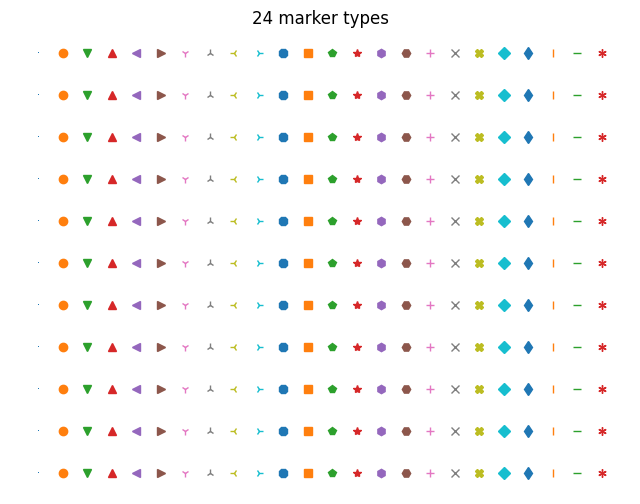

In [4]:
markers = [',','o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*',
           'h', 'H', '+', 'x', 'X', 'D', 'd', '|', '_', (6, 2, 0)]

# Create data
m = len(markers) # markers
n = 10  # lines
xs = np.arange(n+1)      
ys = np.arange(m+1)
Y, X = np.meshgrid(xs, ys)

fig, ax = plt.subplots(figsize=(8, 6))
for x, y, mkr in zip(X, Y, markers):
    ax.plot(x,y, marker= mkr, ls= 'none')

ax.set_axis_off()
ax.set_title(f'{m} marker types')
plt.show()


<a id='fillstyle'></a>
#### Custom Marker Styling - Face and Edge Colors

Here we explore the possibility of creating markers that are partially solid

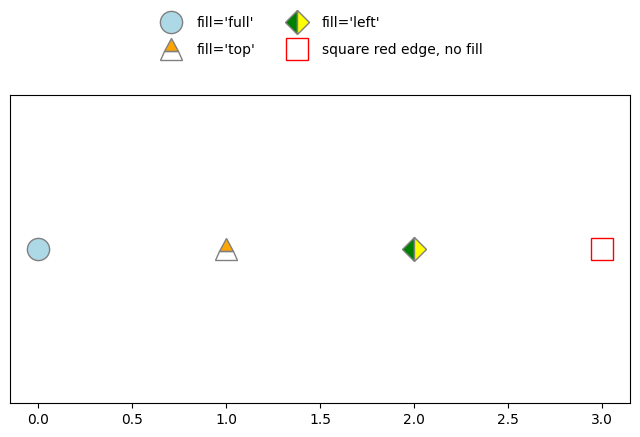

In [5]:
fig, ax = plt.subplots(figsize=(8,4))

# marker with different fillstyles and edge/face colors
ax.plot(0, 2, marker='o', linestyle='None',
         markeredgecolor='gray', markeredgewidth=1,
         markerfacecolor='lightblue', fillstyle='full',
         markersize=16, label="fill='full'")

ax.plot(1, 2, marker='^', linestyle='None',
         markeredgecolor='gray', markeredgewidth=1,
         markerfacecolor='orange', fillstyle='top', markersize=16,
         label="fill='top'")

# markerfacecoloralt is used with split fillstyles (left/right/top/bottom)
ax.plot(2, 2, marker='D', linestyle='None',
         markeredgecolor='gray', markeredgewidth=1,
         markerfacecolor='green', markerfacecoloralt='yellow',
         fillstyle='left', markersize=12,
         label="fill='left'")

# demonstrate different edge width
ax.plot(3, 2, marker='s', linestyle='None',
         markeredgecolor='red', markeredgewidth=1,
         markerfacecolor='none', markersize=16,
         label="square red edge, no fill")

ax.legend(ncol=2, bbox_to_anchor=(0.5, 1.3), loc='upper center',
           labelspacing=1.0, frameon= False )
ax.set_yticks([])
plt.show()

<a id='makevery'></a>
**`markevery`** 

The parameter `markevery` controls which markers will be plotted. You may want to use it whenever you have too many datapoints or if you want to highlight some specific ones. 

- `None` - Mark every point (default)
- `int` - Mark every Nth point. E.g. markevery=5 marks every 5th point
- `(start, N)` - Start at index start, then every Nth point. E.g. markevery=(2, 3) marks indices 2, 5, 8, 11...
- `slice()` - Use Python slice notation. E.g. markevery=slice(0, 10, 2) marks indices 0, 2, 4, 6, 8
- `list` or `array` - Mark specific indices. E.g. markevery=[0, 5, 10, 15] marks only these indices
- `float` - Mark approximately this fraction of points. E.g. markevery=0.1 marks about 10% of points. Matplotlib converts the fraction f to a step N = int(1/f). Then it marks about every N‑th point. E.g.f = 0.13: N = int(1/0.13) = int(7.692...) = 7

Let's explore this parameter


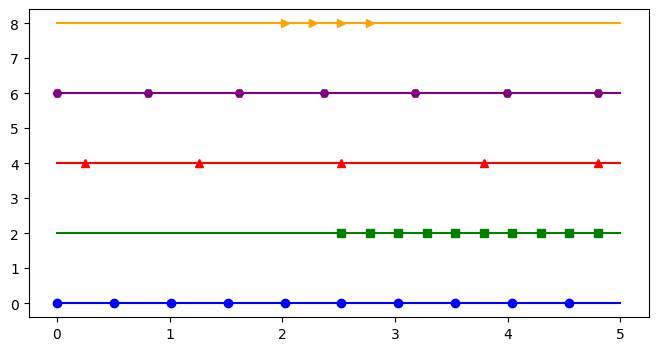

In [6]:
# create data
x = np.linspace(0, 5, 100)
y = np.ones_like(x)

fig, ax = plt.subplots(figsize=(8, 4))

# Mark points based on a slice - horizontal line at y=8
ax.plot(x, y*8, marker='>', markevery=slice(40,60,5), mfc='orange', color='orange')

# Mark around 13% of points - horizontal line at y=6
ax.plot(x, y*6, marker='H', markevery=0.13, mfc='purple', color='purple')

# Mark specific points 
ax.plot(x, y*4, marker='^', markevery=[5,25,50,75,95], mfc='red', color='red')

# Mark first point at 5 then every 5th 
ax.plot(x, y*2, marker='s', markevery=(50,5), mfc='green', color='green')

# Mark every 10th point
ax.plot(x, y*0, marker='o', markevery=10, mfc='blue', color='blue')

plt.show()


##### Format Strings - The Shortcut Method!

Format strings let you combine color, marker, and line style in ONE string!

*The Logic:*
```python
ax.plot(x, y, '[color][marker][line]')
```
**Colors (single character):**
- `'r'` = red, `'g'` = green, `'b'` = blue
- `'c'` = cyan, `'m'` = magenta, `'y'` = yellow
- `'k'` = black, `'w'` = white

**Markers:**
- `'o'` = circle, `'s'` = square
- `'^'` = triangle up, `'v'` = triangle down
- `'*'` = star, `'+'` = plus, `'x'` = x
- `'D'` = diamond

**Lines:**
- `'-'` = solid, `'--'` = dashed
- `'-.'` = dash-dot, `':'` = dotted

```{important}
The order is flexible! All of these work:
- `'ro-'` (color-marker-line)
- `'r-o'` (color-line-marker)  
- `'-ro'` (line-color-marker)
- `'o-r'` (marker-line-color)
```

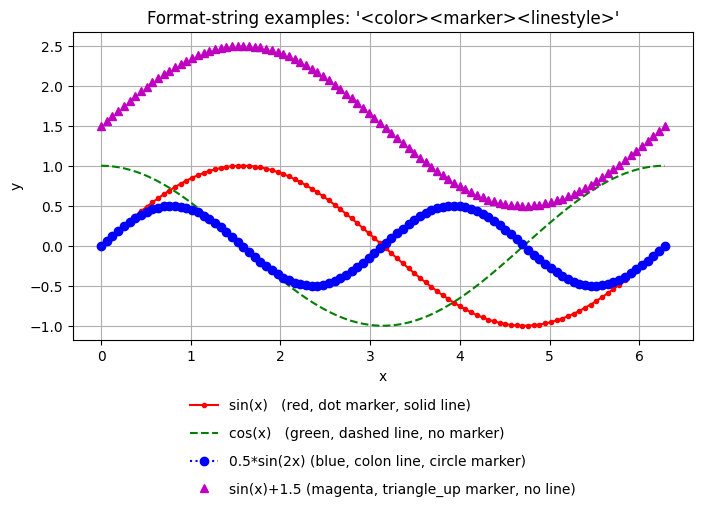

In [7]:
x = np.linspace(0, 2 * np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = 0.5 * np.sin(2*x)
y4 = np.sin(x) + 1.5

fig, ax = plt.subplots(figsize=(8, 4))

# format strings: color, marker, linestyle combined
ax.plot(x, y1, 'r.-',  label="sin(x)   (red, dot marker, solid line)")   # red, point marker, solid line
ax.plot(x, y2, 'g--',  label="cos(x)   (green, dashed line, no marker)")  # green, dashed line
ax.plot(x, y3, 'b:o',  label="0.5*sin(2x) (blue, colon line, circle marker)")  # blue, dotted line with circle markers
ax.plot(x, y4, 'm^',   label="sin(x)+1.5 (magenta, triangle_up marker, no line)")  # magenta triangle markers, no line

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title("Format-string examples: '<color><marker><linestyle>'")
ax.legend(loc='center', bbox_to_anchor=(0.5 , -0.35), labelspacing=1, frameon= False)
ax.grid(True)
plt.show()

**When to Use Format Strings vs Explicit Parameters?**

*Use Format Strings when:*
- You need basic styling with standard colors
- You want quick, concise code
- You're doing exploratory plotting

*Use Explicit Parameters when:*
- You need custom colors (hex codes, RGB tuples)
- You want to set line width, marker size, transparency, etc.
- Code readability is important (e.g., in publications)

You can combine both

## 4. Fill_between - `fill_between()`

Fills the area between two curves (or a curve and a baseline). `fill_betweenx()'  is the transposed version that fills between vertical curves. 

> ```python
> fill_between(x, y1, y2=0, ...)
> fill_betweenx(y, x1, x2=0, ...)
> ```

**Main fill_between parameters:**

- `x` :  Default: None. Defines horizontal coordinates for fill_between. Must align in length with y1 (and y2 if array‑like).
- `y1` : Default: required. First curve values (top or left curve depending on function).
- `y2` : Default: 0. Second curve or baseline to fill to.
- `where` : Default: None. Boolean array (same length as x) or mask; only fill where where is True. If None, fill across the whole domain.
- `interpolate`: Default: False. When True, edges are interpolated at boundaries of where so the filled polygon closes exactly at crossing points.
- `step`: Default: None. None, 'pre', 'post', or 'mid'; makes the filled region follow a step function aligned to the x samples.
- `data`: Default: None. Allows passing x, y1, y2 as keys in a data dict (matplotlib’s data= convenience).
- **kwargs (styling) — Default: varies (None). Sandard artist properties: color / facecolor; edgecolor; alpha (float 0–1); linewidth (numeric); label (string); hatch (string).


I think you could create a horizon plot by breaking up the data
you make three plots, each plotting absolute data values
you map fill color to a +/- function (or variable)
you transform each graph to start at y=zero

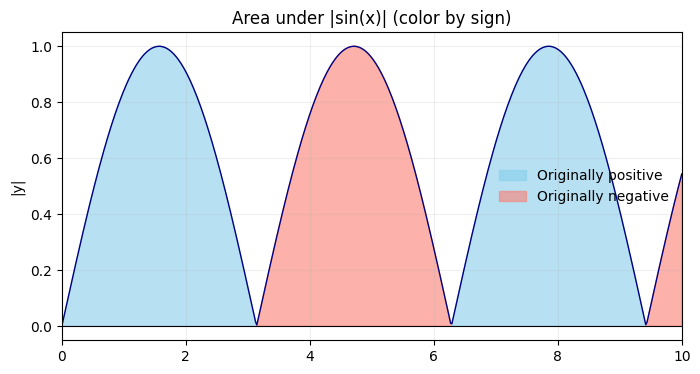

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

x = np.linspace(0, 10, 500)
y = np.sin(x)

y_abs = np.abs(y)

# Fill for originally positive values (blue)
ax.fill_between(
    x, y_abs, 0,
    where=(y >= 0),
    interpolate=True,
    color='skyblue',
    alpha=0.6,
    label='Originally positive'
)

# Fill for originally negative values (red)
ax.fill_between(
    x, y_abs, 0,
    where=(y < 0),
    interpolate=True,
    color='salmon',
    alpha=0.6,
    label='Originally negative'
)

# Plot absolute-value curve
ax.plot(x, y_abs, color='navy', lw=1)

ax.axhline(0, color='black', lw=0.8)
ax.set_title('Area under |sin(x)| (color by sign)')
ax.set_ylabel('|y|')
ax.set_xlim(x.min(), x.max())
ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.show()


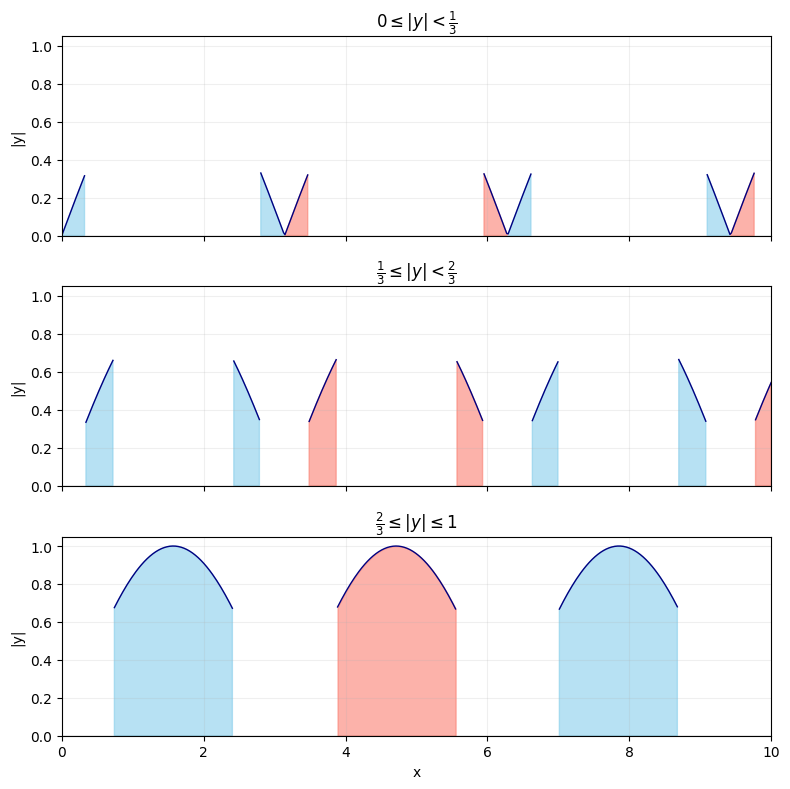

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(0, 10, 500)
y = np.sin(x)
y_abs = np.abs(y)

# Define ranges
ranges = [
    (0, 1/3, r'$0 \leq |y| < \frac{1}{3}$'),
    (1/3, 2/3, r'$\frac{1}{3} \leq |y| < \frac{2}{3}$'),
    (2/3, 1.0, r'$\frac{2}{3} \leq |y| \leq 1$')
]

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

for ax, (low, high, title) in zip(axes, ranges):

    # Mask values outside the band
    band = (y_abs >= low) & (y_abs < high)

    y_band = np.where(band, y_abs, np.nan)

    # Positive original values
    ax.fill_between(
        x, y_band, 0,
        where=(band & (y >= 0)),
        interpolate=True,
        color='skyblue',
        alpha=0.6
    )

    # Negative original values
    ax.fill_between(
        x, y_band, 0,
        where=(band & (y < 0)),
        interpolate=True,
        color='salmon',
        alpha=0.6
    )

    # Boundary curve
    ax.plot(x, y_band, color='navy', lw=1)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel('|y|')
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.axhline(0, color='black', lw=0.8)

axes[-1].set_xlim(x.min(), x.max())
axes[-1].set_xlabel('x')

plt.tight_layout()
plt.show()


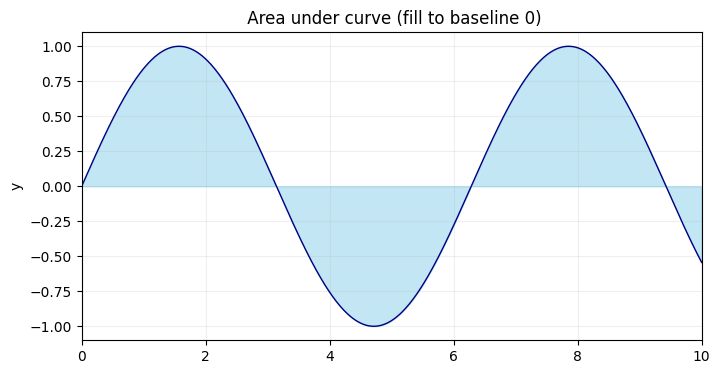

In [10]:
# Create figure with axes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 500)               # dense sampling for a smooth polygon
y = np.sin(x)

# Fill between y and baseline 0; set color and transparency
ax.fill_between(x, y, color='skyblue', alpha=0.5)
ax.plot(x, y, color='navy', lw=1)  # draw the boundary on top
ax.set_title(' Area under curve (fill to baseline 0)')
ax.set_ylabel('y')
ax.set_xlim(x.min(), x.max())
ax.grid(alpha=0.2)

plt.show()

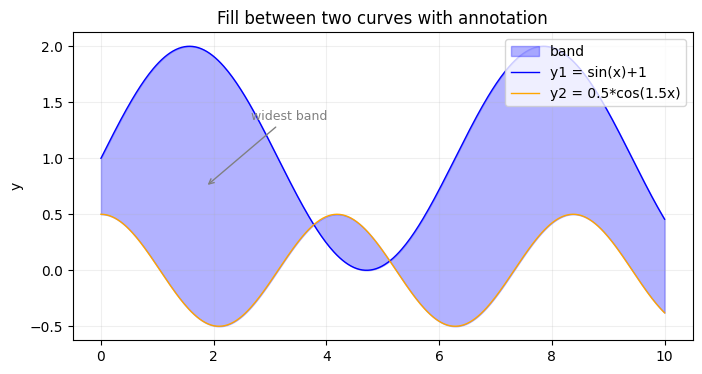

In [11]:
# Create figure with axes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 400)
y1 = np.sin(x) + 1.0                       # shifted sine
y2 = 0.5 * np.cos(1.5 * x)                 # faster, lower-amplitude cosine

# Fill the band between y1 and y2 with transparency and label
ax.fill_between(x, y1, y2, color='blue', alpha=0.3, label='band')
ax.plot(x, y1, color='blue', lw=1, label='y1 = sin(x)+1')
ax.plot(x, y2, color='orange', lw=1, label='y2 = 0.5*cos(1.5x)')
ax.set_title('Fill between two curves with annotation')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

# Annotate the x position where the band is widest (max absolute difference)
idx_widest = np.argmax(np.abs(y1 - y2))
x_widest = x[idx_widest]
y_mid = 0.5 * (y1[idx_widest] + y2[idx_widest])
ax.annotate('widest band',
            xy=(x_widest, y_mid),
            xytext=(x_widest + 0.8, y_mid + 0.6),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9,
            color='gray')
plt.show()

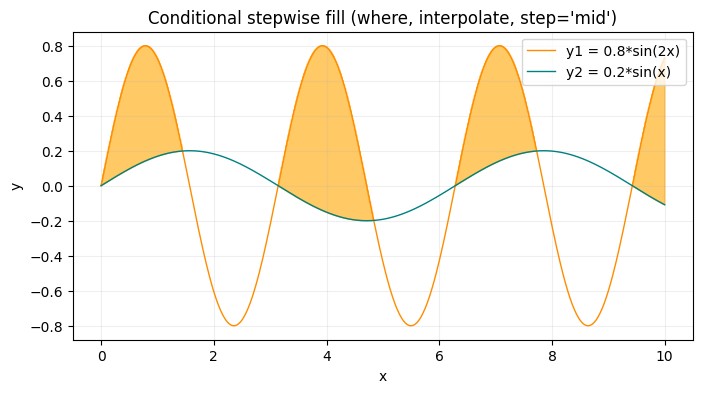

In [12]:
# Create figure with axes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 500)
y1 = 0.8 * np.sin(2 * x)
y2 = 0.2 * np.sin(x)

# boolean mask selecting intervals to fill
where_mask= y1 > y2
# Use where to restrict filling, interpolate to close polygons at boundaries,
# and step='mid' to follow a stepwise shape
ax.fill_between(x, y1, y2, where=where_mask, interpolate=True,
                step='mid', color='orange', alpha=0.6)
ax.plot(x, y1, color='darkorange', lw=1, label='y1 = 0.8*sin(2x)')
ax.plot(x, y2, color='teal', lw=1, label='y2 = 0.2*sin(x)')
ax.set_title("Conditional stepwise fill (where, interpolate, step='mid')")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

plt.show()

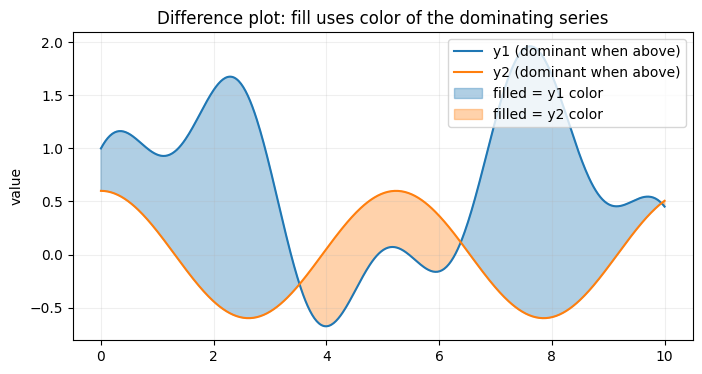

In [13]:
# Create figure with axes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 500)
y1 = np.sin(x) + 0.5 * np.cos(2.5 * x) + 0.5   # series A
y2 = 0.6 * np.cos(1.2 * x)                     # series B

ax.plot(x, y1, color='tab:blue', lw=1.5, label='y1 (dominant when above)')
ax.plot(x, y2, color='tab:orange', lw=1.5, label='y2 (dominant when above)')

# Masks where each series dominates
mask_y1 = y1 >= y2
mask_y2 = ~mask_y1

# Fill where y1 >= y2 using y1's color; interpolate to close polygons at crossings
ax.fill_between(x, y1, y2, where=mask_y1, interpolate=True,
                color='tab:blue', alpha=0.35, label='filled = y1 color')

# Fill where y2 > y1 using y2's color
ax.fill_between(x, y1, y2, where=mask_y2, interpolate=True,
                color='tab:orange', alpha=0.35, label='filled = y2 color')

ax.set_title('Difference plot: fill uses color of the dominating series')
ax.set_ylabel('value')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

plt.show()

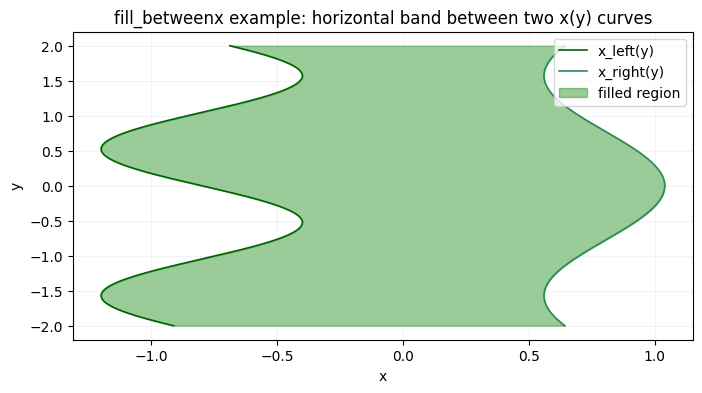

In [14]:
# Create figure with axes
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Create data
y = np.linspace(-2, 2, 400)
# left and right x-curves as functions of y
x_left = -0.8 * (1 + 0.5 * np.sin(3 * y))
x_right =  0.8 * (1 + 0.3 * np.cos(2 * y))

# Plot the boundary curves
ax.plot(x_left, y, color='darkgreen', lw=1.2, label='x_left(y)')
ax.plot(x_right, y, color='seagreen', lw=1.2, label='x_right(y)')

# Fill horizontally between x_left and x_right across y
ax.fill_betweenx(y, x_left, x_right, color='green', alpha=0.4, label='filled region')

ax.set_title('fill_betweenx example: horizontal band between two x(y) curves')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.grid(alpha=0.15)

plt.show()